In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!unzip "/content/drive/MyDrive/flowers.zip" -d /content/dataset

Archive:  /content/drive/MyDrive/flowers.zip
   creating: /content/dataset/flowers/
   creating: /content/dataset/flowers/daisy/
  inflating: /content/dataset/flowers/daisy/100080576_f52e8ee070_n.jpg  
  inflating: /content/dataset/flowers/daisy/10140303196_b88d3d6cec.jpg  
  inflating: /content/dataset/flowers/daisy/10172379554_b296050f82_n.jpg  
  inflating: /content/dataset/flowers/daisy/10172567486_2748826a8b.jpg  
  inflating: /content/dataset/flowers/daisy/10172636503_21bededa75_n.jpg  
  inflating: /content/dataset/flowers/daisy/102841525_bd6628ae3c.jpg  
  inflating: /content/dataset/flowers/daisy/1031799732_e7f4008c03.jpg  
  inflating: /content/dataset/flowers/daisy/10391248763_1d16681106_n.jpg  
  inflating: /content/dataset/flowers/daisy/10437754174_22ec990b77_m.jpg  
  inflating: /content/dataset/flowers/daisy/10437770546_8bb6f7bdd3_m.jpg  
  inflating: /content/dataset/flowers/daisy/10437929963_bc13eebe0c.jpg  
  inflating: /content/dataset/flowers/daisy/10466290366_cc72e

In [5]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, image_dataset_from_directory

data_dir = "/content/dataset/flowers"

# creating training data
train_data = image_dataset_from_directory(data_dir, validation_split= 0.2, subset = 'training',
                                          seed = 42, image_size = (224,224), batch_size = 32,
                                          crop_to_aspect_ratio = True)

# creating validation data
val_data = image_dataset_from_directory(data_dir, validation_split= 0.2, subset = 'validation',
                                          seed = 42, image_size = (224,224), batch_size = 32,
                                          crop_to_aspect_ratio = True)

# making base model
base_model = MobileNetV2(weights = 'imagenet', include_top = False, input_shape = (224, 224, 3))

# freezing base model
base_model.trainable = False

# adding a model on top
inputs = Input(shape = (224, 224, 3))
x = Lambda(preprocess_input)(inputs)
x = base_model(x, training = False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(5, activation = 'softmax')(x)
model = Model(inputs, outputs)

# compiling the model
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# training the model
model.fit(train_data, validation_data = val_data, epochs = 10)

# Unfreezing some layers for fine-tuning
tuning_layer = 100
base_model.trainable = True
for layer in base_model.layers[:tuning_layer]:
  layer.trainable = False

# Recompiling the model
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.00001),
              loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

# fine-tuning the model
model.fit(train_data, validation_data = val_data, epochs = 10)


Found 3680 files belonging to 5 classes.
Using 2944 files for training.
Found 3680 files belonging to 5 classes.
Using 736 files for validation.
Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7266 - loss: 0.7634 - val_accuracy: 0.8696 - val_loss: 0.4219
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.8855 - loss: 0.3582 - val_accuracy: 0.8818 - val_loss: 0.3390
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9107 - loss: 0.2778 - val_accuracy: 0.8777 - val_loss: 0.3212
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.9283 - loss: 0.2305 - val_accuracy: 0.8954 - val_loss: 0.3216
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - accuracy: 0.9416 - loss: 0.2020 - val_accuracy: 0.8845 - val_loss: 0.3067
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 213s 2s/step - accuracy: 0.9511 - loss: 0.1750 - val_accuracy: 0.8967 - val_loss: 0.2806
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.9609 - loss: 0.1541 - val_ac

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


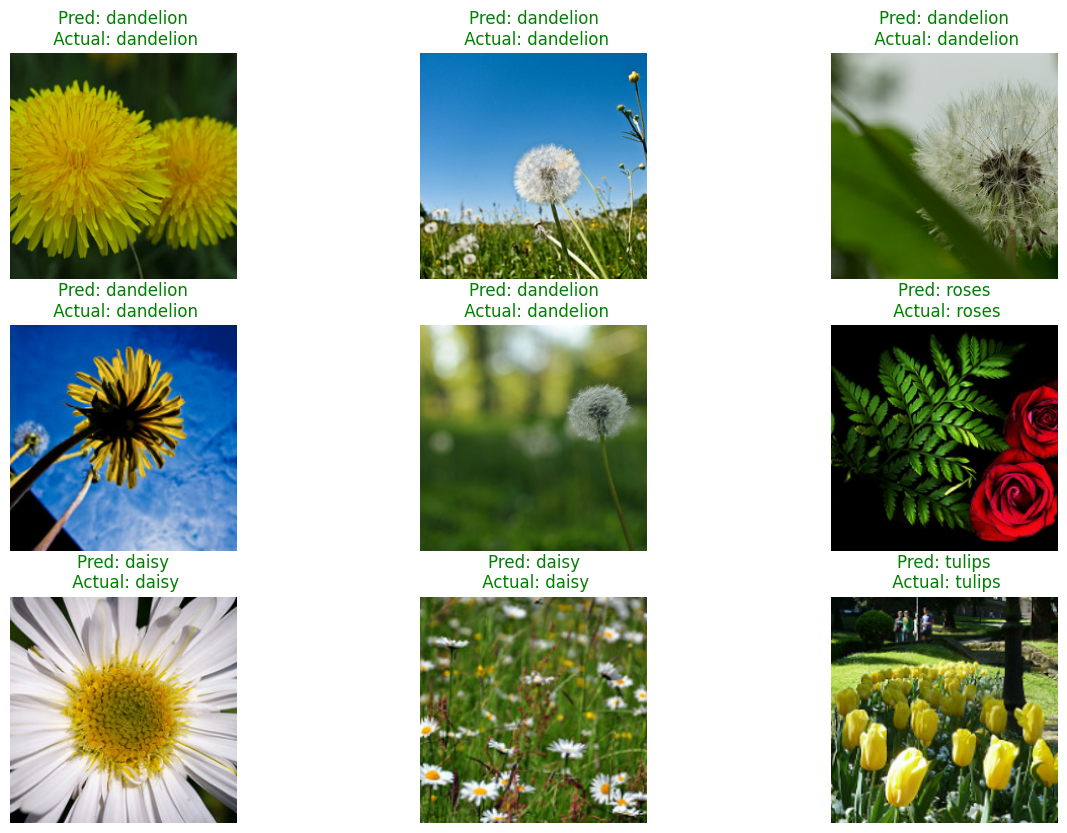

In [10]:
import matplotlib.pyplot as plt
import numpy as np

flower_names = train_data.class_names

image_batch, label_batch = next(iter(val_data))

prediction = model.predict(image_batch)

# making the plot
plt.figure(figsize = (15, 10))

for i in range (9):

  ax = plt.subplot(3, 3, i+1)

  plt.imshow(image_batch[i].numpy().astype('uint8'))

  pred_index = np.argmax(prediction[i])

  actual_index = label_batch[i].numpy()

  colour = 'green' if pred_index == actual_index else 'red'

  plt.title(f'Pred: {flower_names[pred_index]}\n Actual: {flower_names[actual_index]}', color = colour)
  plt.axis('off')

In [11]:
model.save('flower_classifier_model.keras')